In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path
import os

import numpy as np
import seaborn as sns
import os
from analysis.utils import load_sweep_metadata, load_data, compute_success, chunk_data
from analysis.utils_decoding import evaluate_lags_leave_k_out

## Load results 

In [3]:
# Load the decoding results
results_decoding = {}
with open(
        '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_sac_vs_tdmpc2/results_decoding_future_linear_regression_passive_data_pixel_vs_state.pkl',
        'rb') as f:
    results_decoding['linear_regression_future'] = pickle.load(f)

In [5]:
path = "/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_sac_vs_tdmpc2/"


def load_decoding_results(path, predict_type, model):
    """Load decoding results from pickle file."""
    with open(
            os.path.join(
                path,
                f'results_decoding_{predict_type}_{model}_passive_data_pixel_vs_state.pkl'
            ), 'rb') as f:
        return pickle.load(f)


# Load all combinations
results_decoding = {}
for model in ['linear_regression', 'lasso', 'mlp']:
    for predict_type in ['future']:
        key = f'{predict_type}_{model}'
        results_decoding[key] = load_decoding_results(path, predict_type, model)

In [ ]:
results_decoding.keys()

dict_keys(['future_linear_regression', 'difference_linear_regression', 'future_lasso', 'difference_lasso'])

## Decoding

In [ ]:
decoding_relationships = [
    ('position', 'position'),
    ('cos(pole_angle)', 'cos(pole_angle)'),
    ('sin(pole_angle)', 'sin(pole_angle)'),
    ('cart_velocity', 'cart_velocity'),
    ('pole_angular_velocity', 'pole_angular_velocity'),
    ('rewards', 'rewards'),
    ('actions', 'actions'),
    ('z_tdmpc2_state', 'position'),
    ('z_tdmpc2_state', 'cos(pole_angle)'),
    ('z_tdmpc2_state', 'sin(pole_angle)'),
    ('z_tdmpc2_state', 'cart_velocity'),
    ('z_tdmpc2_state', 'pole_angular_velocity'),
    ('z_tdmpc2_state', 'rewards'),
    ('z_tdmpc2_state', 'actions'),
    ('z_tdmpc2_pixel', 'position'),
    ('z_tdmpc2_pixel', 'cos(pole_angle)'),
    ('z_tdmpc2_pixel', 'sin(pole_angle)'),
    ('z_tdmpc2_pixel', 'cart_velocity'),
    ('z_tdmpc2_pixel', 'pole_angular_velocity'),
    ('z_tdmpc2_pixel', 'rewards'),
    ('z_tdmpc2_pixel', 'actions'),
]


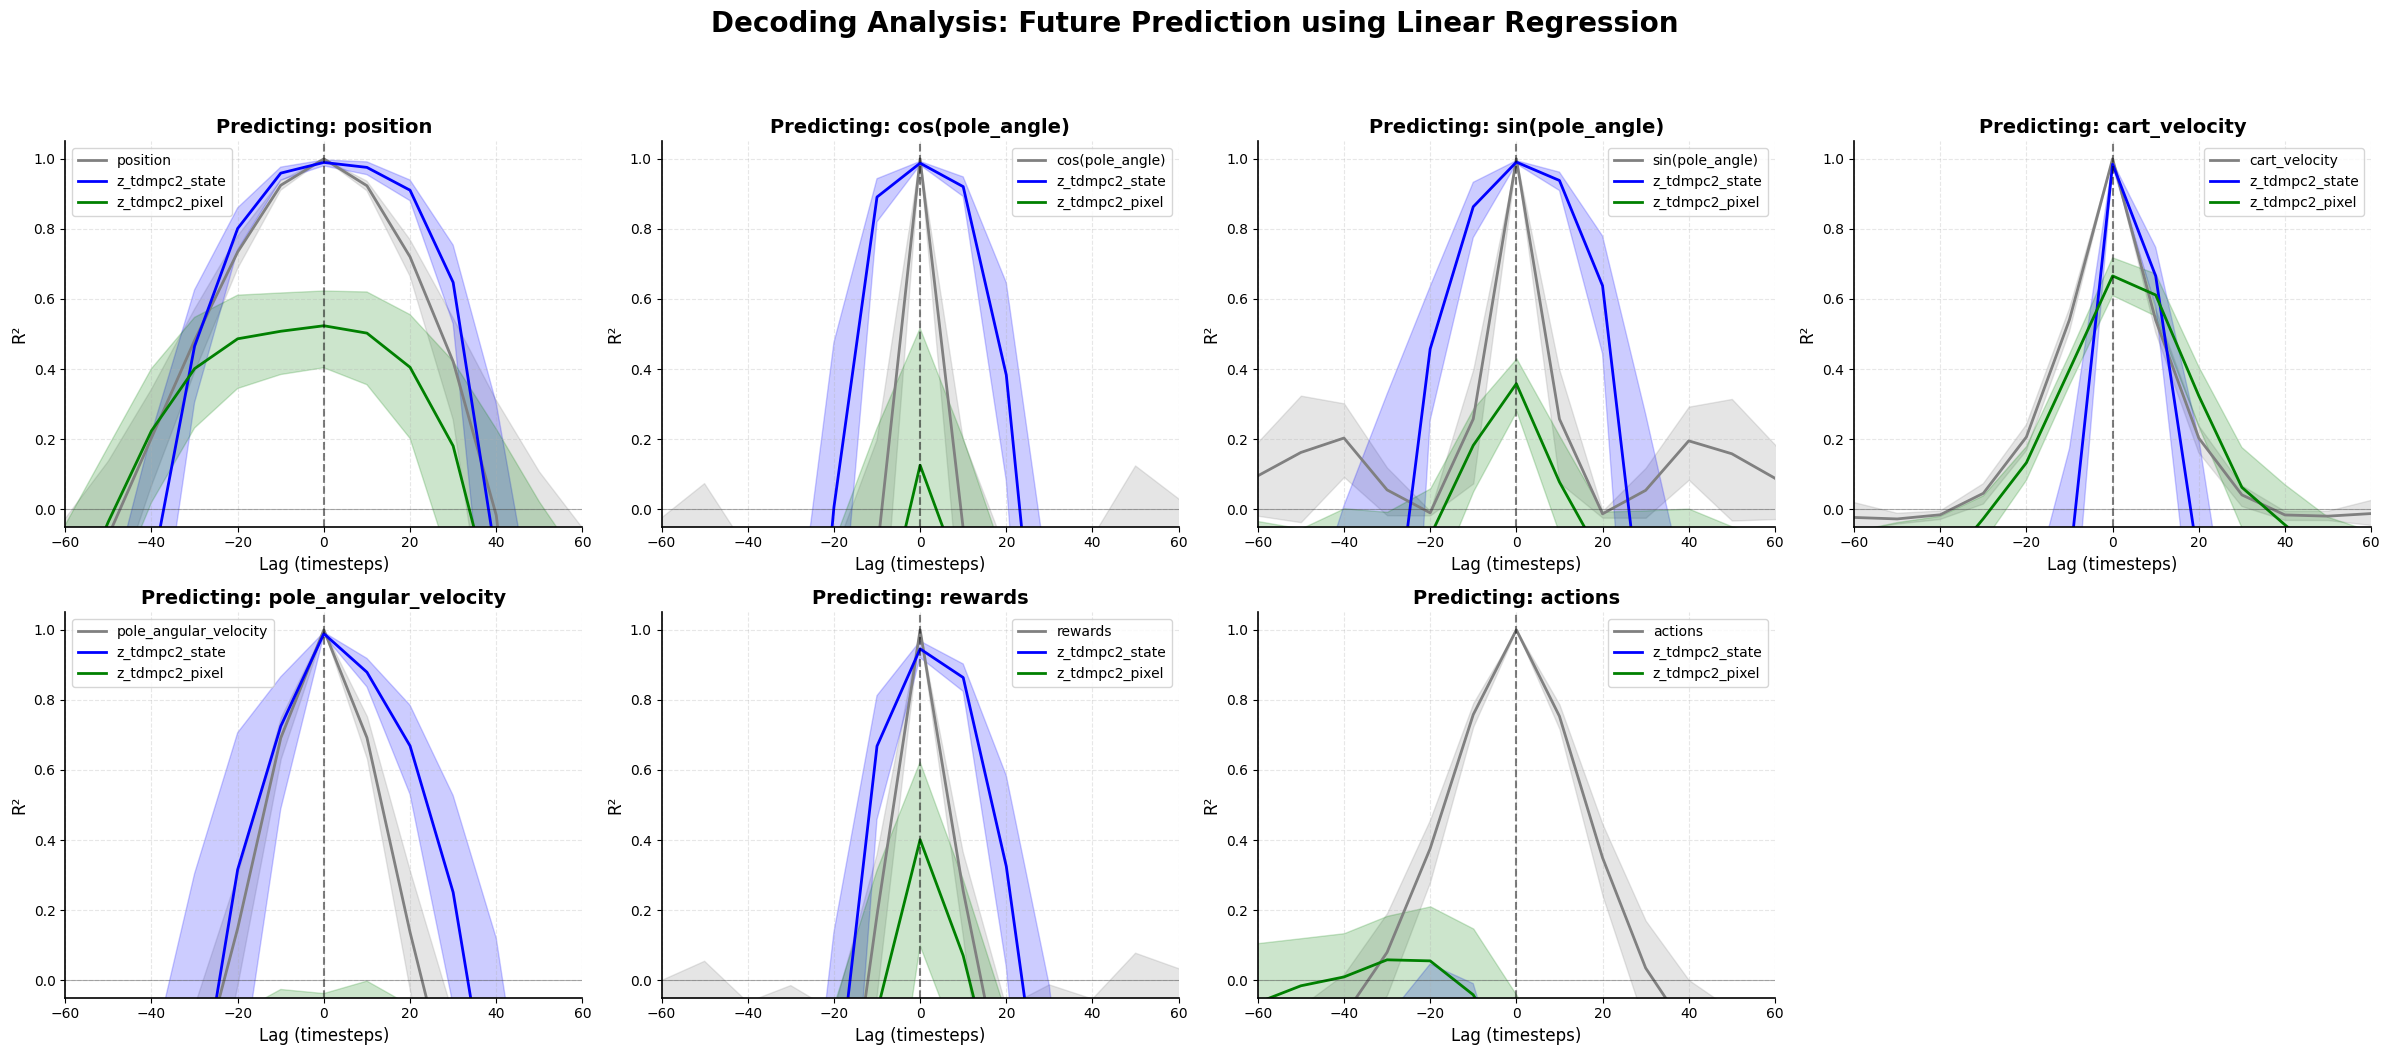

In [ ]:
# Group plot keys by y variable
y_variables = [
    'position',
    'cos(pole_angle)',
    'sin(pole_angle)',
    'cart_velocity',
    'pole_angular_velocity',
    'rewards',
    'actions',
]

# Create figure with 2 rows and enough columns for all y variables
n_vars = len(y_variables)
n_cols = (n_vars + 1) // 2  # Ceiling division to get number of columns needed
fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 6, 10))
axes = axes.flatten()  # Flatten to make indexing easier

regression_type = 'future'
model = 'linear_regression'

# Define colors for each x variable type
color_map = {
    'z_sac': 'red',
    'z_tdmpc2_state': 'blue',
    'z_tdmpc2_pixel': 'green',
    'position': 'gray',
    'cos(pole_angle)': 'gray',
    'sin(pole_angle)': 'gray',
    'cart_velocity': 'gray',
    'pole_angular_velocity': 'gray',
    'rewards': 'gray',
    'actions': 'gray'
}

for idx, y_var in enumerate(y_variables):
    # Get all x variables that predict this y variable
    plot_keys = [(x_var, y_var)
                 for x_var, y_var_check in decoding_relationships
                 if y_var_check == y_var]

    if not plot_keys:
        continue

    ax = axes[idx]

    # Plot each x variable as a separate line
    for x_var, _ in plot_keys:
        key = f'{x_var}-{y_var}'

        if key in results_decoding[f'{regression_type}_{model}']:
            results = results_decoding[f'{regression_type}_{model}'][key]

            r2_mean = results['r2_mean']
            r2_ci = results['r2_ci']
            lags = list(r2_mean.keys())
            means = list(r2_mean.values())
            ci_lower = [r2_ci[lag][0] for lag in lags]
            ci_upper = [r2_ci[lag][1] for lag in lags]

            color = color_map.get(x_var, 'black')
            ax.plot(lags, means, linewidth=2, label=x_var, color=color)
            ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2, color=color)

    ax.set_xlabel('Lag (timesteps)', fontsize=12)
    ax.set_ylabel('R²', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-60, 60)
    ax.tick_params(labelsize=10)
    ax.set_title(f'Predicting: {y_var}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# Hide any unused subplots
for idx in range(len(y_variables), len(axes)):
    axes[idx].set_visible(False)

# Add overall title
fig.suptitle(
    f'Decoding Analysis: {regression_type.capitalize()} Prediction using {model.replace("_", " ").title()}',
    fontsize=20,
    fontweight='bold',
    y=1.05)

plt.tight_layout()
sns.despine()
plt.show()

In [7]:
scores

{'train_r2_mean': {0: 0.9998706976572672},
 'train_r2_std': {0: 2.4738355420058303e-05},
 'test_r2_mean': {0: 0.9883195877075195},
 'test_r2_std': {0: 0.0119166735050481},
 'train_r2_by_lag': {0: [0.9998682141304016,
   0.9998888969421387,
   0.9998616576194763,
   0.9998513460159302,
   0.9998887777328491,
   0.9998934864997864,
   0.999882161617279,
   0.9999077320098877,
   0.9998767971992493,
   0.9998761415481567,
   0.9998742341995239,
   0.9998476505279541,
   0.9998064637184143,
   0.9998868703842163,
   0.9998500347137451]},
 'test_r2_by_lag': {0: [0.9910430312156677,
   0.9971579909324646,
   0.9952951073646545,
   0.9742944240570068,
   0.9964049458503723,
   0.9546012282371521,
   0.9802751541137695,
   0.9815660119056702,
   0.991790235042572,
   0.9983195662498474,
   0.983002781867981,
   0.9962897896766663,
   0.9952071309089661,
   0.9925367832183838,
   0.9970096349716187]},
 'model_by_lag': {0: [Pipeline(steps=[('scaler', StandardScaler()),
                   ('mlp',

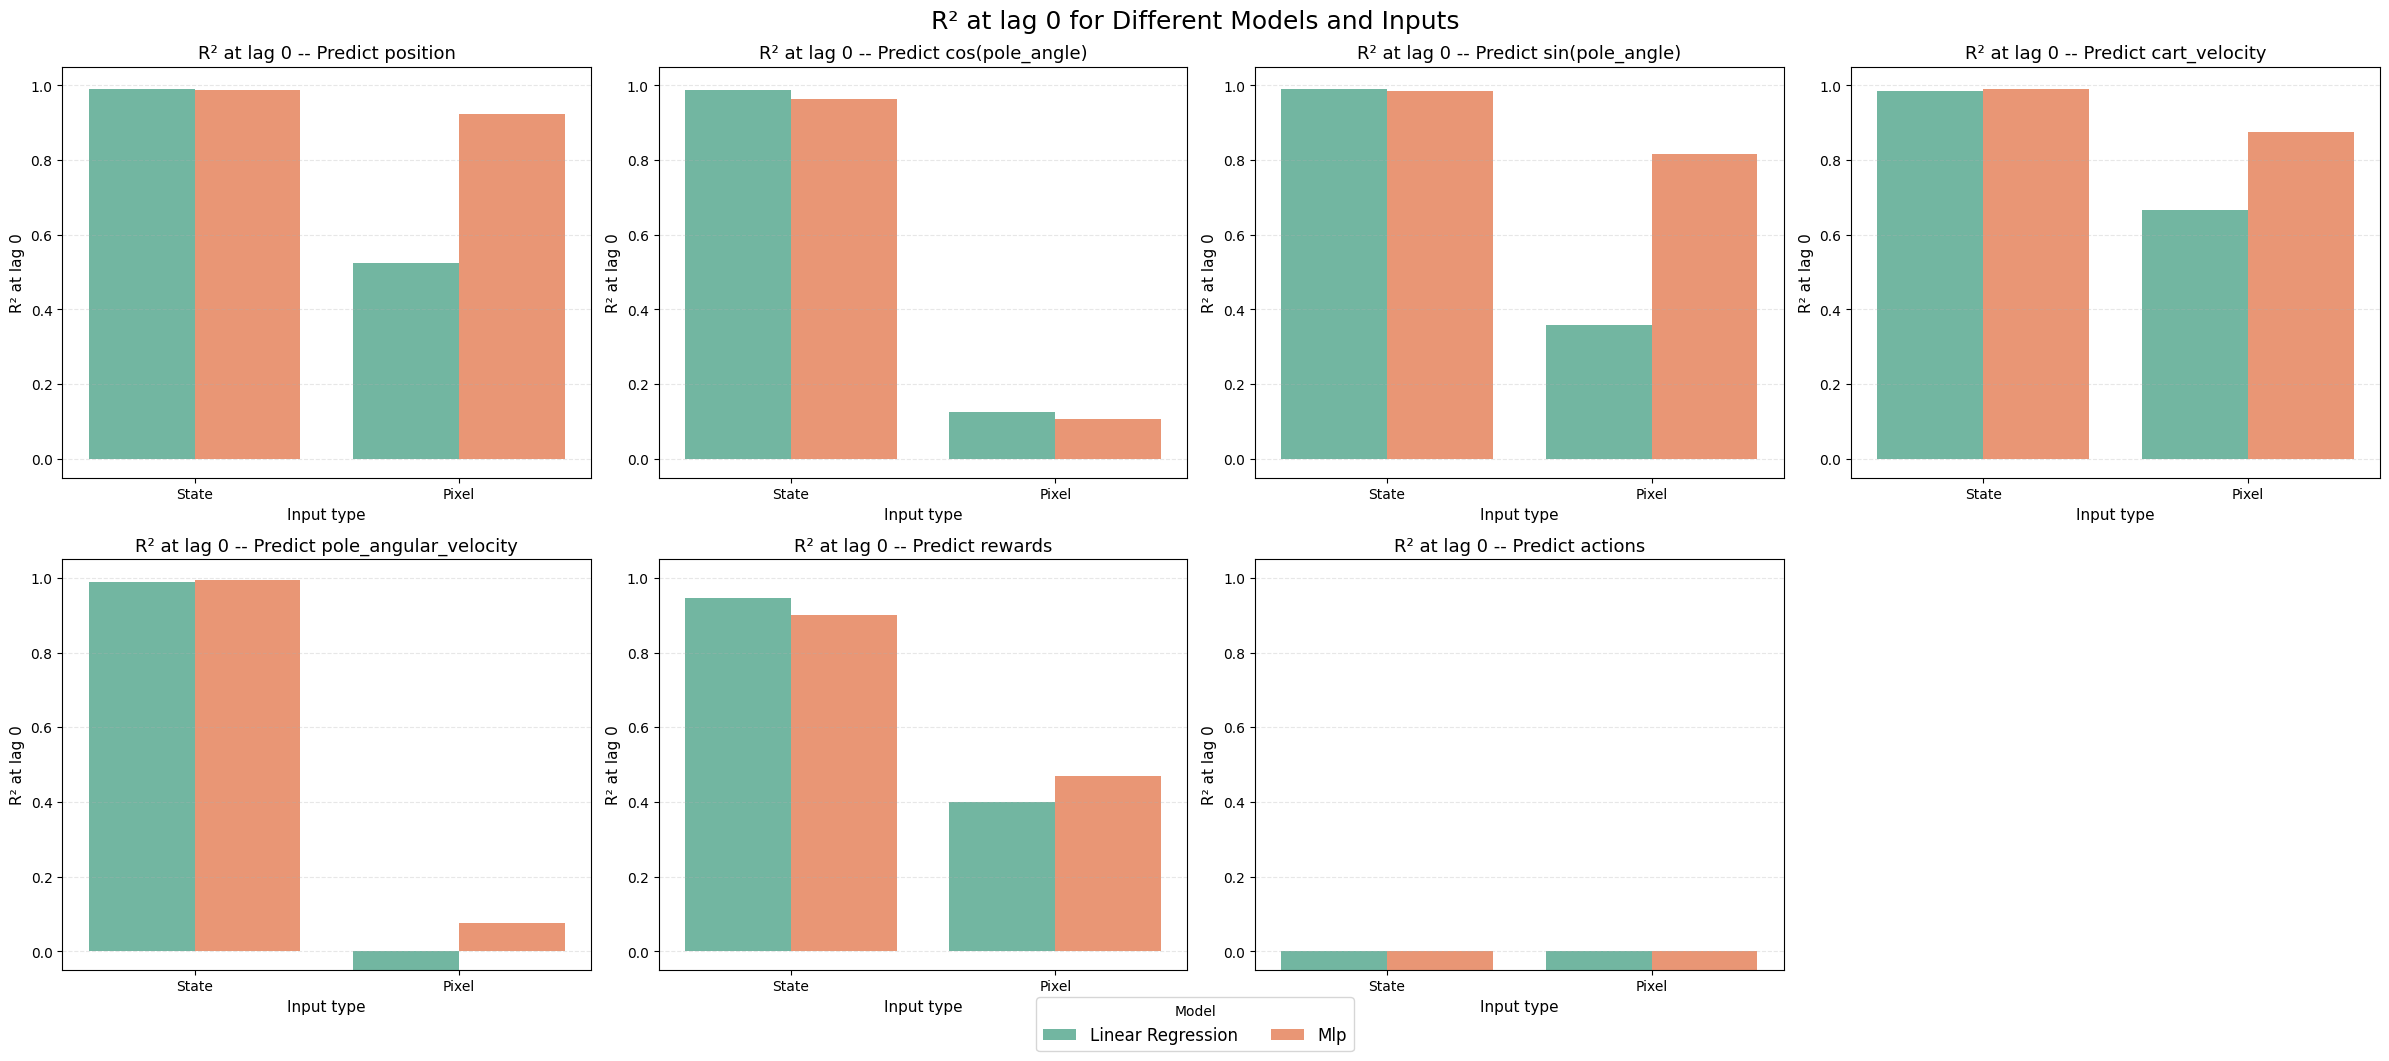

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Arrange bar plots for each y variable (e.g., 'position', ...) in a grid with 4 per row

models = ['linear_regression', 'mlp']
input_types = ['z_tdmpc2_state', 'z_tdmpc2_pixel']
regression_type = 'future'
y_variables = [
    'position',
    'cos(pole_angle)',
    'sin(pole_angle)',
    'cart_velocity',
    'pole_angular_velocity',
    'rewards',
    'actions',
]

n_vars = len(y_variables)
n_cols = 4
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()

legend_handles = []
legend_labels = []
added_legend_keys = set()

for idx, y_var_of_interest in enumerate(y_variables):
    bar_data = []
    for model in models:
        for input_type in input_types:
            key = f'{input_type}-{y_var_of_interest}'
            scores = results_decoding.get(f'{regression_type}_{model}',
                                          {}).get(key, {})
            if scores:
                r2_at_0 = scores['r2_mean' if model !=
                                 'mlp' else 'test_r2_mean'].get(0, np.nan)
                bar_data.append({
                    'Input type':
                        'State' if input_type.endswith('state') else 'Pixel',
                    'Model':
                        model.replace('_', ' ').title(),
                    'R² at lag 0':
                        r2_at_0
                })
    df_bar = pd.DataFrame(bar_data)
    ax = axes[idx]
    g = sns.barplot(x='Input type',
                    y='R² at lag 0',
                    hue='Model',
                    data=df_bar,
                    palette='Set2',
                    ax=ax,
                    errorbar=None)
    ax.set_title(f'R² at lag 0 -- Predict {y_var_of_interest}', fontsize=13)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('R² at lag 0', fontsize=11)
    ax.set_xlabel('Input type', fontsize=11)
    # Don't show the legend in the subplot
    legend = ax.get_legend()
    if legend is not None:
        handles, labels = ax.get_legend_handles_labels()
        # Collect unique (label, handle) pairs across all axes
        for h, l in zip(handles, labels):
            if l not in added_legend_keys:
                legend_handles.append(h)
                legend_labels.append(l)
                added_legend_keys.add(l)
        ax.legend_.remove()
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# Hide any unused axes if total subplots > y_variables
for idx in range(len(y_variables), len(axes)):
    axes[idx].set_visible(False)

fig.tight_layout()
fig.suptitle('R² at lag 0 for Different Models and Inputs', fontsize=18, y=1.02)

# Create a single, outside legend for all subplots (centered under figure)
fig.legend(legend_handles,
           legend_labels,
           loc='lower center',
           fontsize=12,
           title='Model',
           ncol=len(legend_labels),
           bbox_to_anchor=(0.5, -0.03))

plt.show()